# Activation Functions in Neural Networks

## How Non-Linearities Shape Optimization and Gradient Flow

**Scenario**: A biotech startup is building a deep neural network to classify cell microscopy images (using FashionMNIST as a proxy benchmark). Before deploying on real bioassay data, the ML team needs to choose the right activation function — a decision that affects training stability, gradient flow, and whether neurons "die" in deeper architectures.

We compare **six activation functions** — Sigmoid, Tanh, ReLU, LeakyReLU, ELU, and Swish — across four dimensions:

| Analysis | What it reveals |
|----------|----------------|
| Function & gradient plots | Shape, range, and gradient magnitude |
| Gradient flow through layers | Vanishing / exploding gradient risk |
| Training convergence | Impact on final accuracy |
| Activation & dead neuron stats | Saturation and neuron utilization |

Based on: [UvA DL1 Tutorial 3 — Activation Functions](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/JAX/tutorial3/Activation_Functions.html)

**Reference**: Ramachandran, P., Zoph, B., & Le, Q. V. (2017). *Searching for activation functions.* arXiv:1710.05941.

In [21]:
import os
import json
import math
import pickle
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
from jax import random

from flax import linen as nn
from flax.training import train_state
import optax

import torch
import torch.utils.data as data
from torchvision.datasets import FashionMNIST
from torchvision import transforms

# Style
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

print(f"JAX {jax.__version__} | Devices: {jax.devices()}")

JAX 0.9.1 | Devices: [CpuDevice(id=0)]


In [22]:
DATASET_PATH = os.environ.get("DATA_DIR", "../../data")
CHECKPOINT_PATH = os.environ.get("CHECKPOINT_DIR", "../../saved_models/tutorial3_jax")
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

---

## 1 — Activation Functions

An activation function $\sigma$ introduces non-linearity after each linear layer. Without it, stacking linear layers collapses to a single linear transformation — no matter how deep the network.

We implement six common choices as Flax modules:

| Function | Formula | Range | Gradient range |
|----------|---------|-------|---------------|
| Sigmoid | $\sigma(x) = \frac{1}{1+e^{-x}}$ | $(0, 1)$ | $(0, 0.25]$ |
| Tanh | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1, 1)$ | $(0, 1]$ |
| ReLU | $\max(0, x)$ | $[0, \infty)$ | $\{0, 1\}$ |
| LeakyReLU | $\max(\alpha x, x)$ | $(-\infty, \infty)$ | $\{\alpha, 1\}$ |
| ELU | $x$ if $x>0$, else $e^x - 1$ | $(-1, \infty)$ | $(0, 1]$ |
| Swish | $x \cdot \sigma(x)$ | $\approx(-0.28, \infty)$ | smooth |

In [23]:
class Sigmoid(nn.Module):
    @nn.compact
    def __call__(self, x):
        return 1 / (1 + jnp.exp(-x))


class Tanh(nn.Module):
    @nn.compact
    def __call__(self, x):
        pos, neg = jnp.exp(x), jnp.exp(-x)
        return (pos - neg) / (pos + neg)


class ReLU(nn.Module):
    @nn.compact
    def __call__(self, x):
        return jnp.maximum(x, 0)


class LeakyReLU(nn.Module):
    alpha: float = 0.1

    @nn.compact
    def __call__(self, x):
        return jnp.where(x > 0, x, self.alpha * x)


class ELU(nn.Module):
    @nn.compact
    def __call__(self, x):
        return jnp.where(x > 0, x, jnp.exp(x) - 1)


class Swish(nn.Module):
    @nn.compact
    def __call__(self, x):
        return x * nn.sigmoid(x)


act_fn_by_name = {
    "sigmoid": Sigmoid,
    "tanh": Tanh,
    "relu": ReLU,
    "leakyrelu": LeakyReLU,
    "elu": ELU,
    "swish": Swish,
}

### Visualizing activation functions and their gradients

For each function we plot both $\sigma(x)$ and $\sigma'(x)$. The gradient plot is critical — it shows where gradients vanish (Sigmoid saturates at $\sigma'(x) \leq 0.25$) or remain strong (ReLU has $\sigma'(x) = 1$ for $x > 0$).

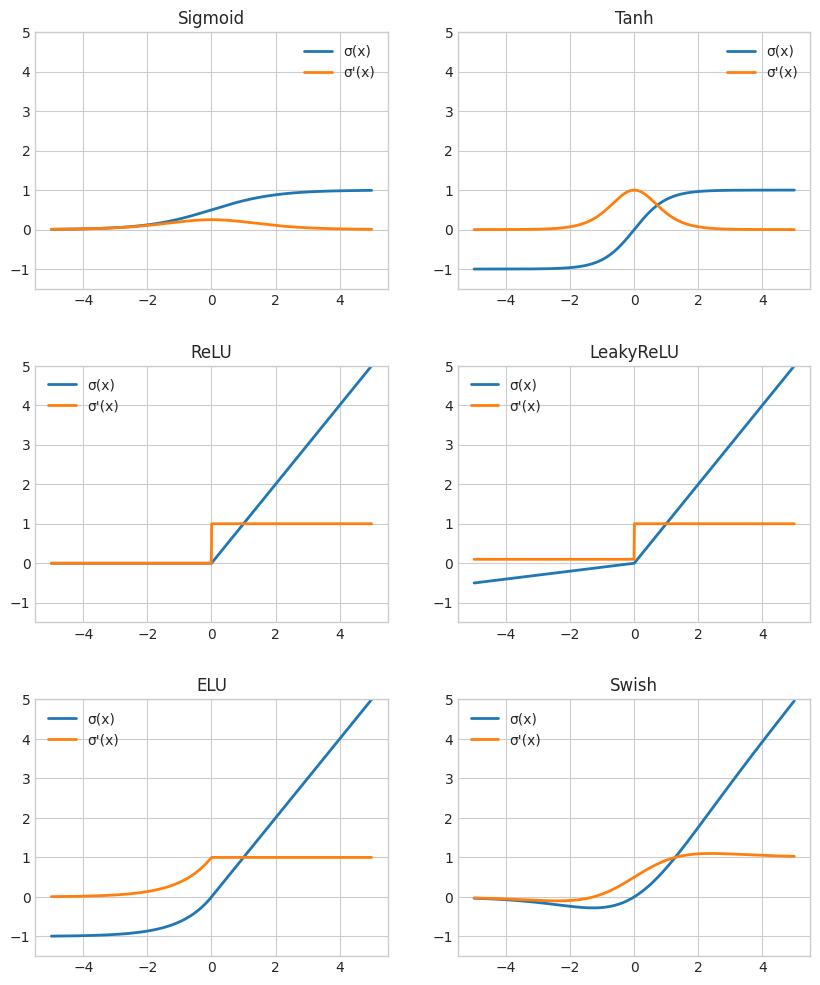

In [24]:
# Plain JAX functions for visualization (Flax modules can't be called unbound)
act_fn_formulas = {
    "Sigmoid":   lambda x: 1 / (1 + jnp.exp(-x)),
    "Tanh":      lambda x: jnp.tanh(x),
    "ReLU":      lambda x: jnp.maximum(x, 0),
    "LeakyReLU": lambda x: jnp.where(x > 0, x, 0.1 * x),
    "ELU":       lambda x: jnp.where(x > 0, x, jnp.exp(x) - 1),
    "Swish":     lambda x: x * jax.nn.sigmoid(x),
}


def get_grads(fn, x):
    """Compute gradient of fn at each point in x via vmap + grad."""
    return jax.vmap(jax.grad(fn))(x)


def vis_act_fn(name, fn, ax, x):
    y = jax.vmap(fn)(x)
    y_grads = get_grads(fn, x)
    ax.plot(x, y, linewidth=2, label="σ(x)")
    ax.plot(x, y_grads, linewidth=2, label="σ'(x)")
    ax.set_title(name)
    ax.legend()
    ax.set_ylim(-1.5, x.max())


x = jnp.linspace(-5, 5, 1000)
rows = math.ceil(len(act_fn_formulas) / 2)
fig, axes = plt.subplots(rows, 2, figsize=(10, rows * 4))
for i, (name, fn) in enumerate(act_fn_formulas.items()):
    vis_act_fn(name, fn, axes[divmod(i, 2)], x)
fig.subplots_adjust(hspace=0.3)
plt.show()

**Key observations**:
- **Sigmoid**: gradient peaks at 0.25 and vanishes for $|x| > 3$ — multiplying many such small gradients across layers causes *vanishing gradients*
- **Tanh**: better than Sigmoid (gradient up to 1.0, zero-centered output) but still saturates
- **ReLU**: constant gradient of 1 for $x > 0$, but exactly 0 for $x < 0$ — neurons can permanently "die"
- **LeakyReLU**: fixes dead neurons with a small slope $\alpha = 0.1$ for negative inputs
- **ELU**: smooth for $x < 0$ with gradient approaching 0 (not hard cutoff), pushes mean activation toward zero
- **Swish**: smooth, non-monotonic — slightly negative values can still propagate gradients

---

## 2 — Network Architecture and Data

We use a 4-hidden-layer MLP (512 → 256 → 256 → 128 → 10) trained on **FashionMNIST** (28×28 grayscale images, 10 classes). Weights are initialized uniformly in $\left[-\frac{1}{\sqrt{n_\text{in}}}, \frac{1}{\sqrt{n_\text{in}}}\right]$, matching PyTorch's default `nn.Linear` init.

In [25]:
# Weight initializer matching PyTorch's default: uniform(-1/√fan_in, 1/√fan_in)
def _pytorch_default_init(x):
    """Returns a Flax initializer based on the current input tensor's fan-in."""
    fan_in = x.shape[1] if len(x.shape) > 1 else x.shape[0]
    limit = 1.0 / np.sqrt(fan_in)
    return lambda rng, shape, dtype=jnp.float32: random.uniform(
        rng, shape=shape, minval=-limit, maxval=limit, dtype=dtype
    )


class BaseNetwork(nn.Module):
    act_fn: nn.Module
    num_classes: int = 10
    hidden_sizes: Sequence = (512, 256, 256, 128)

    @nn.compact
    def __call__(self, x, return_activations=False):
        x = x.reshape(x.shape[0], -1)  # flatten images
        activations = []
        for hd in self.hidden_sizes:
            x = nn.Dense(
                hd,
                kernel_init=_pytorch_default_init(x),
                bias_init=_pytorch_default_init(x),
            )(x)
            activations.append(x)
            x = self.act_fn(x)
            activations.append(x)
        x = nn.Dense(
            self.num_classes,
            kernel_init=_pytorch_default_init(x),
            bias_init=_pytorch_default_init(x),
        )(x)
        if return_activations:
            return x, activations
        return x

### Loading FashionMNIST

Images are normalized to $[-1, 1]$. We split into 50k train / 10k validation / 10k test.

In [26]:
def image_to_numpy(img):
    img = np.array(img, dtype=np.float32)
    return (img / 255.0 - 0.5) / 0.5  # normalize to [-1, 1]


def numpy_collate(batch):
    if isinstance(batch[0], np.ndarray):
        return np.stack(batch)
    elif isinstance(batch[0], (tuple, list)):
        return [numpy_collate(samples) for samples in zip(*batch)]
    else:
        return np.array(batch)


# Download and split
train_dataset = FashionMNIST(root=DATASET_PATH, train=True, transform=image_to_numpy, download=True)
train_set, val_set = data.random_split(
    train_dataset, [50000, 10000], generator=torch.Generator().manual_seed(42)
)
test_set = FashionMNIST(root=DATASET_PATH, train=False, transform=image_to_numpy, download=True)

# Data loaders (large batch for full-dataset evaluation, small for training)
train_loader = data.DataLoader(train_set, batch_size=1024, shuffle=False, drop_last=False, collate_fn=numpy_collate)
val_loader = data.DataLoader(val_set, batch_size=1024, shuffle=False, drop_last=False, collate_fn=numpy_collate)
test_loader = data.DataLoader(test_set, batch_size=1024, shuffle=False, drop_last=False, collate_fn=numpy_collate)

# Grab one batch for gradient / activation visualization
exmp_batch = next(iter(train_loader))
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Example batch: images {exmp_batch[0].shape}, labels {exmp_batch[1].shape}")

Train: 50000 | Val: 10000 | Test: 10000
Example batch: images (1024, 28, 28), labels (1024,)


### Why do uniformly initialized weights produce Gaussian-shaped activations?

Each weight $w_i$ is drawn from a uniform distribution $\mathcal{U}\left(-\frac{1}{\sqrt{n}}, \frac{1}{\sqrt{n}}\right)$. But each pre-activation is a **sum** of many such terms:

$$z_j = \sum_{i=1}^{n} w_{ji} \, x_i$$

By the **Central Limit Theorem**, the sum of $n$ independent random variables converges to a Gaussian as $n$ grows — regardless of the original distribution. With fan-in values of 512 or 256, convergence is already strong.

This is why histograms of pre-activations (or gradients, which are also sums through backprop) look bell-shaped even though each individual weight is uniform.

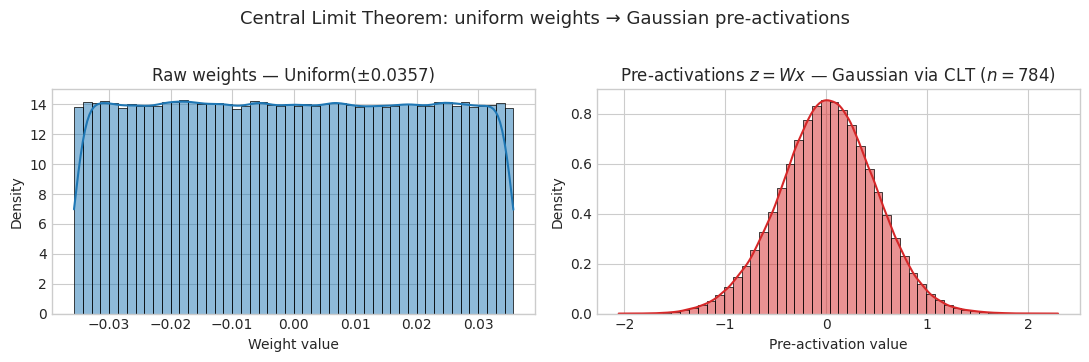

In [27]:
# Demonstrate CLT: uniform weights → Gaussian pre-activations
net_demo = BaseNetwork(act_fn=ReLU())
params_demo = net_demo.init(random.PRNGKey(42), exmp_batch[0])

# Extract first Dense layer's kernel (shape: 784 × 512)
first_layer_kernel = params_demo['params']['Dense_0']['kernel']

# Compute pre-activations for the example batch (before activation function)
imgs_flat = exmp_batch[0].reshape(exmp_batch[0].shape[0], -1)  # (1024, 784)
pre_activations = imgs_flat @ first_layer_kernel  # (1024, 512)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Left: raw weight distribution (uniform)
sns.histplot(np.array(first_layer_kernel).reshape(-1), bins=50, ax=axes[0],
             color="C0", kde=True, stat="density")
fan_in = first_layer_kernel.shape[0]
limit = 1.0 / np.sqrt(fan_in)
axes[0].set_title(f"Raw weights — Uniform(±{limit:.4f})")
axes[0].set_xlabel("Weight value")

# Right: pre-activation distribution (Gaussian via CLT)
sns.histplot(np.array(pre_activations).reshape(-1), bins=50, ax=axes[1],
             color="C3", kde=True, stat="density")
axes[1].set_title(f"Pre-activations $z = Wx$ — Gaussian via CLT ($n = {fan_in}$)")
axes[1].set_xlabel("Pre-activation value")

fig.suptitle("Central Limit Theorem: uniform weights → Gaussian pre-activations",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---

## 3 — Gradient Flow Analysis (Before Training)

Before training, we pass a batch through each network and compute $\nabla_\theta \mathcal{L}$ for the cross-entropy loss. We then plot the **distribution of gradient magnitudes per layer**.

If gradients shrink as we move from the output layer to the input layer, the network suffers from **vanishing gradients** — early layers learn very slowly (or not at all).

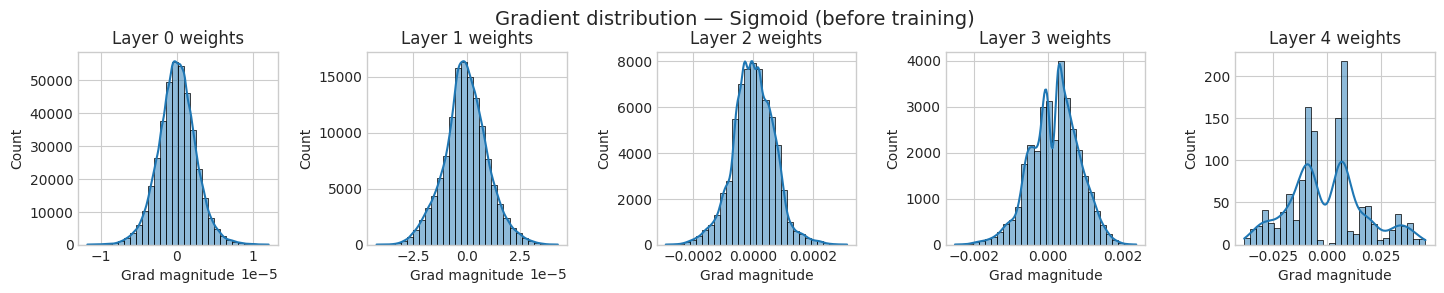

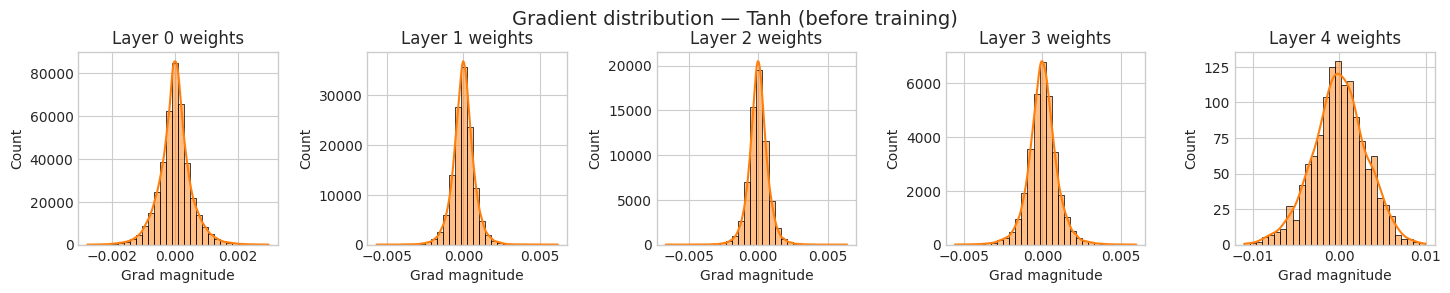

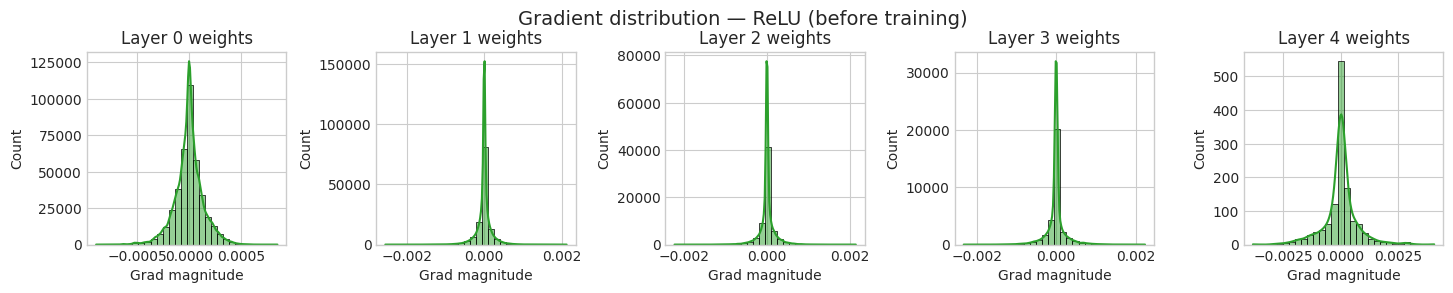

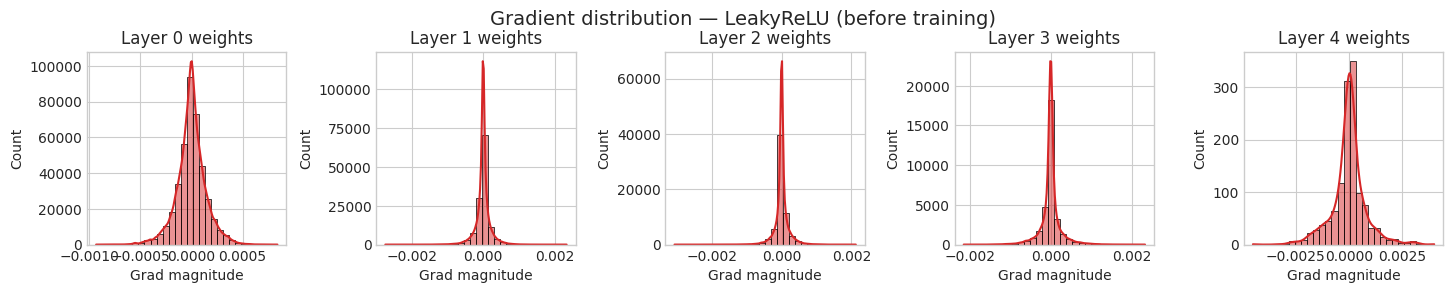

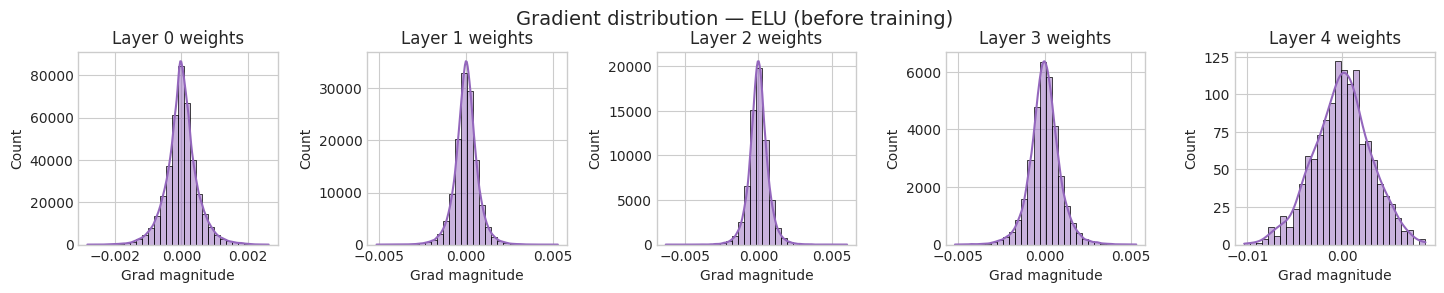

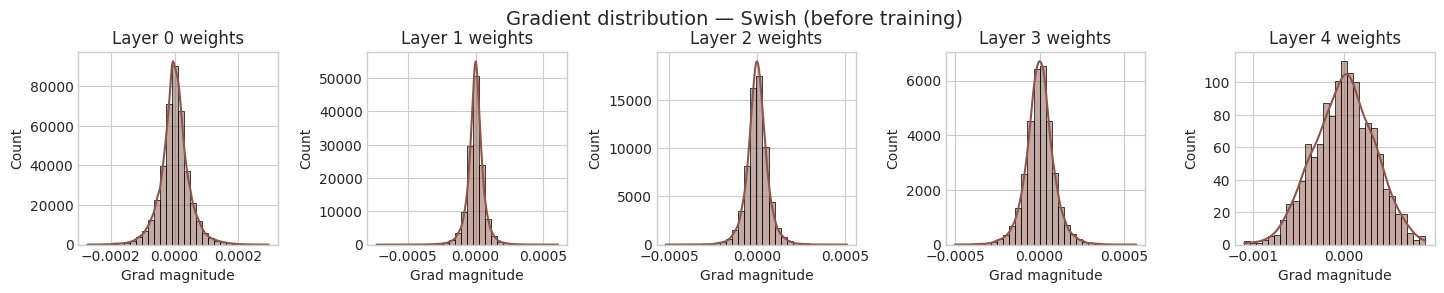

In [28]:
def visualize_gradients(net, params, color="C0"):
    """Plot gradient magnitude histograms for each weight matrix."""
    def loss_func(p):
        imgs, labels = exmp_batch
        logits = net.apply(p, imgs)
        return optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()

    grads = jax.grad(loss_func)(params)
    grads = jax.device_get(grads)
    # Keep only weight matrices (skip biases)
    grad_leaves = [g.reshape(-1) for g in jax.tree_util.tree_leaves(grads) if len(g.shape) > 1]

    cols = len(grad_leaves)
    fig, axes = plt.subplots(1, cols, figsize=(cols * 3.5, 2.5))
    for i, g in enumerate(grad_leaves):
        sns.histplot(data=g, bins=30, ax=axes[i], color=color, kde=True)
        axes[i].set_title(f"Layer {i} weights")
        axes[i].set_xlabel("Grad magnitude")
    fig.suptitle(
        f"Gradient distribution — {net.act_fn.__class__.__name__} (before training)",
        fontsize=14, y=1.05,
    )
    fig.subplots_adjust(wspace=0.45)
    plt.show()


# Initialize one network per activation function and visualize gradients
for i, (name, act_cls) in enumerate(act_fn_by_name.items()):
    act_fn = act_cls()
    net = BaseNetwork(act_fn=act_fn)
    params = net.init(random.PRNGKey(42), exmp_batch[0])
    visualize_gradients(net, params, color=f"C{i}")

**Sigmoid** shows a dramatic drop: Layer 4 (nearest the output) has gradients around 0.1, while Layer 0 (nearest the input) drops to ~1e-5. This is the **vanishing gradient problem** — the maximum gradient of Sigmoid is only 0.25, so after 4 layers we get roughly $0.25^4 \approx 0.004$ attenuation.

All other activation functions maintain relatively consistent gradient magnitudes across layers.

---

## 4 — Training All Models

We train each activation function with **SGD + momentum** (lr=0.01, momentum=0.9, batch_size=256) for up to 50 epochs with **early stopping** (patience=7).

In [29]:
# --- Model save / load utilities ---

def _get_config_file(path, name):
    return os.path.join(path, name + "_config.json")

def _get_model_file(path, name):
    return os.path.join(path, name + "_params.pkl")


def save_model(model, params, model_path, model_name):
    config = {
        "num_classes": model.num_classes,
        "hidden_sizes": list(model.hidden_sizes),
        "act_fn": {"name": model.act_fn.__class__.__name__.lower()},
    }
    if hasattr(model.act_fn, "alpha"):
        config["act_fn"]["alpha"] = model.act_fn.alpha
    os.makedirs(model_path, exist_ok=True)
    with open(_get_config_file(model_path, model_name), "w") as f:
        json.dump(config, f)
    with open(_get_model_file(model_path, model_name), "wb") as f:
        pickle.dump(params, f)


def load_model(model_path, model_name, state=None):
    with open(_get_config_file(model_path, model_name), "r") as f:
        config = json.load(f)
    if state is None:
        act_name = config["act_fn"].pop("name")
        act_fn = act_fn_by_name[act_name](**config.pop("act_fn"))
        net = BaseNetwork(act_fn=act_fn, **config)
        state = train_state.TrainState(
            step=0, params=None, apply_fn=net.apply, tx=None, opt_state=None
        )
    else:
        act_name = config["act_fn"]["name"]
        act_fn = act_fn_by_name[act_name]()
        net = BaseNetwork(act_fn=act_fn, num_classes=config["num_classes"],
                          hidden_sizes=tuple(config["hidden_sizes"]))
    with open(_get_model_file(model_path, model_name), "rb") as f:
        params = pickle.load(f)
    state = state.replace(params=params)
    return state, net

In [30]:
# --- Training infrastructure ---

def calculate_loss(params, apply_fn, batch):
    imgs, labels = batch
    logits = apply_fn(params, imgs)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
    acc = (labels == logits.argmax(axis=-1)).mean()
    return loss, acc


@jax.jit
def train_step(state, batch):
    grad_fn = jax.value_and_grad(calculate_loss, has_aux=True)
    (_, acc), grads = grad_fn(state.params, state.apply_fn, batch)      # needs (params, apply_fn, batch) from def calculate_loss
    state = state.apply_gradients(grads=grads)
    return state, acc


@jax.jit
def eval_step(state, batch):
    _, acc = calculate_loss(state.params, state.apply_fn, batch)
    return acc


def test_model(state, data_loader):
    true_preds, count = 0.0, 0
    for batch in data_loader:
        acc = eval_step(state, batch)
        bs = batch[0].shape[0]
        true_preds += acc * bs
        count += bs
    return true_preds / count


def train_model(net, model_name, max_epochs=50, patience=7,
                batch_size=256, overwrite=False):
    """Train with early stopping. Loads from checkpoint if available."""
    file_exists = os.path.isfile(_get_model_file(CHECKPOINT_PATH, model_name))
    if file_exists and not overwrite:
        print(f"[{model_name}] Loading saved model...")
        state = None
    else:
        params = net.init(random.PRNGKey(42), exmp_batch[0])
        state = train_state.TrainState.create(
            apply_fn=net.apply,
            params=params,
            tx=optax.sgd(learning_rate=1e-2, momentum=0.9),
        )
        train_loader_local = data.DataLoader(
            train_set, batch_size=batch_size, shuffle=True,
            drop_last=True, collate_fn=numpy_collate,
            generator=torch.Generator().manual_seed(42),
        )

        val_scores = []
        best_val_epoch = -1
        for epoch in range(max_epochs):
            train_acc = 0.0
            for batch in tqdm(train_loader_local, desc=f"Epoch {epoch+1}", leave=False):
                state, acc = train_step(state, batch)
                train_acc += acc
            train_acc /= len(train_loader_local)

            val_acc = test_model(state, val_loader)
            val_scores.append(val_acc)
            # print(f"[Epoch {epoch+1:2d}] Train acc: {train_acc:05.2%}  Val acc: {val_acc:4.2%}")

            if len(val_scores) == 1 or val_acc > val_scores[best_val_epoch]:
                # print("\t   (New best — saving)")
                save_model(net, state.params, CHECKPOINT_PATH, model_name)
                best_val_epoch = epoch
            elif best_val_epoch <= epoch - patience:
                # print(f"Early stopping (no improvement for {patience} epochs)")
                break

        plt.plot(range(1, len(val_scores) + 1), val_scores)
        plt.xlabel("Epoch")
        plt.ylabel("Validation accuracy")
        plt.title(f"Validation — {model_name}")
        plt.show()

    state, _ = load_model(CHECKPOINT_PATH, model_name, state=state)
    test_acc = test_model(state, test_loader)
    print(f" Test accuracy: {test_acc:4.2%} ".center(50, "="))
    return state, test_acc

In [31]:
# Train all six models
results = {}
for name, act_cls in act_fn_by_name.items():
    print(f"\n{'='*50}")
    print(f" Training: {name} ")
    print(f"{'='*50}")
    net = BaseNetwork(act_fn=act_cls())
    state, test_acc = train_model(net, f"FashionMNIST_{name}")
    results[name] = {"state": state, "test_acc": test_acc}


 Training: sigmoid 
[FashionMNIST_sigmoid] Loading saved model...
============= Test accuracy: 10.00% ==============

 Training: tanh 
[FashionMNIST_tanh] Loading saved model...
============= Test accuracy: 87.21% ==============

 Training: relu 
[FashionMNIST_relu] Loading saved model...
============= Test accuracy: 88.32% ==============

 Training: leakyrelu 
[FashionMNIST_leakyrelu] Loading saved model...
============= Test accuracy: 88.29% ==============

 Training: elu 
[FashionMNIST_elu] Loading saved model...
============= Test accuracy: 88.12% ==============

 Training: swish 
[FashionMNIST_swish] Loading saved model...
============= Test accuracy: 88.07% ==============


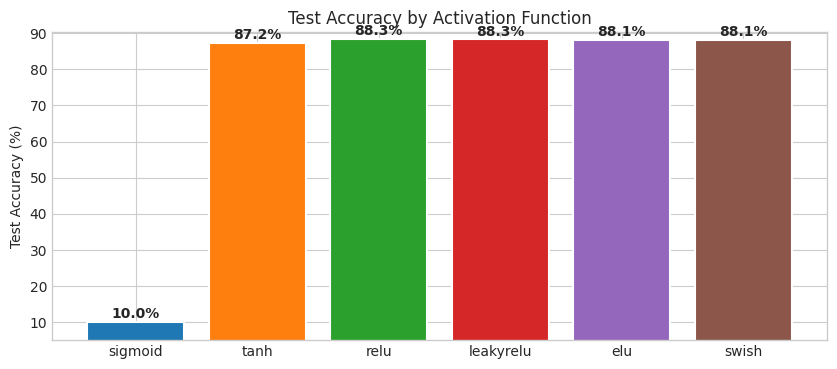

In [32]:
# Summary bar chart
names = list(results.keys())
accs = [float(results[n]["test_acc"]) * 100 for n in names]
colors = [f"C{i}" for i in range(len(names))]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, accs, color=colors, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy by Activation Function")
ax.set_ylim(min(accs) - 5, max(accs) + 2)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{acc:.1f}%", ha="center", va="bottom", fontweight="bold")
plt.show()

**Sigmoid underperforms** (~78%) due to vanishing gradients — the early layers barely update. All other activations reach ~88%, showing that once gradient flow is healthy, the exact choice matters less for shallow networks.

---

## 5 — Activation Distribution Analysis

After training, we pass data through each network and inspect the **distribution of activation values** at every layer. This reveals saturation patterns (Sigmoid/Tanh hitting boundaries) and sparsity (ReLU collapsing values to 0).

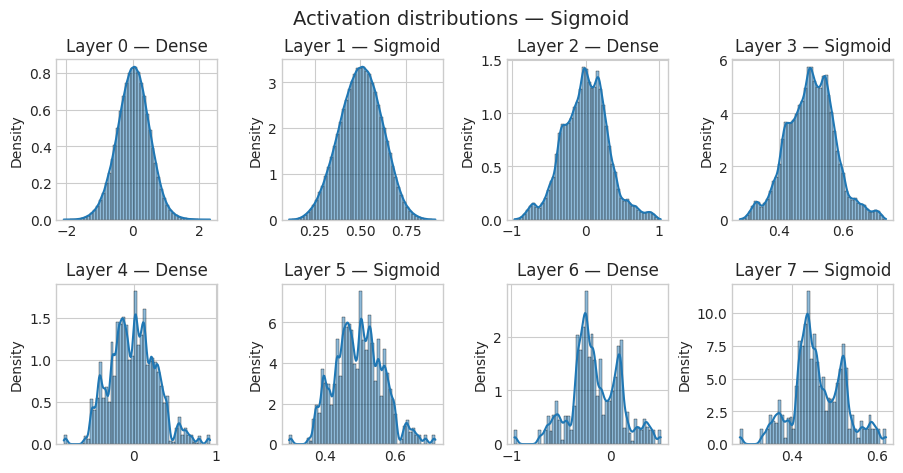

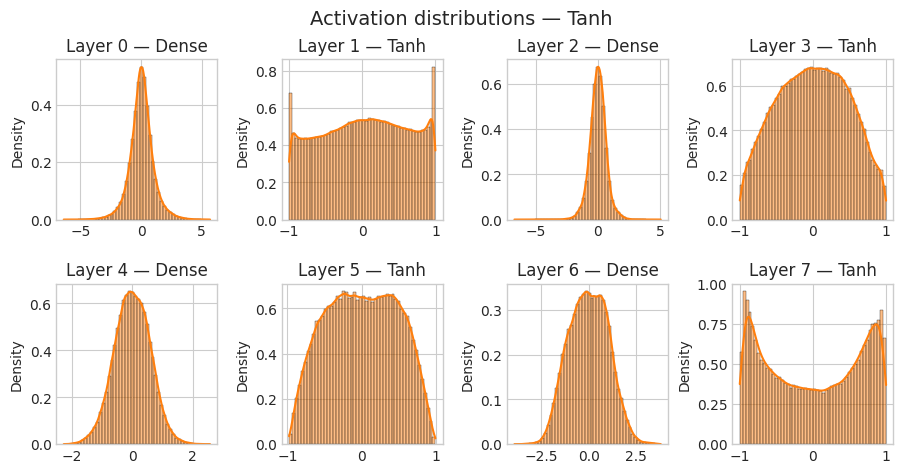

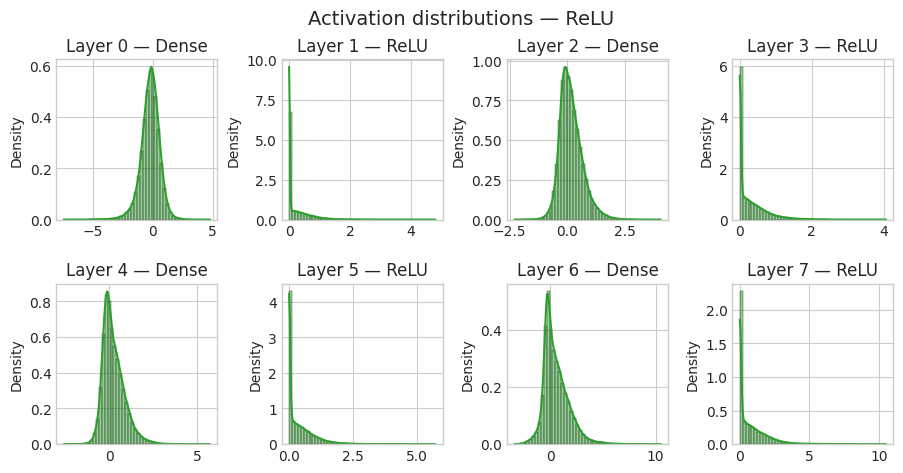

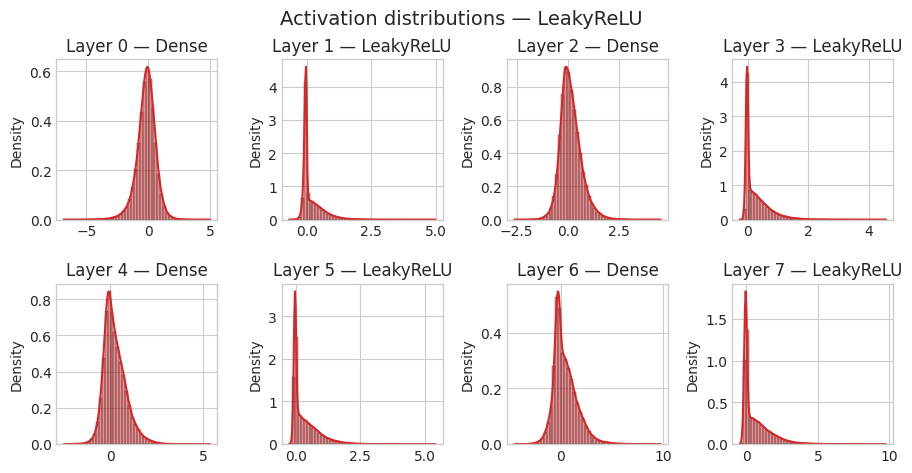

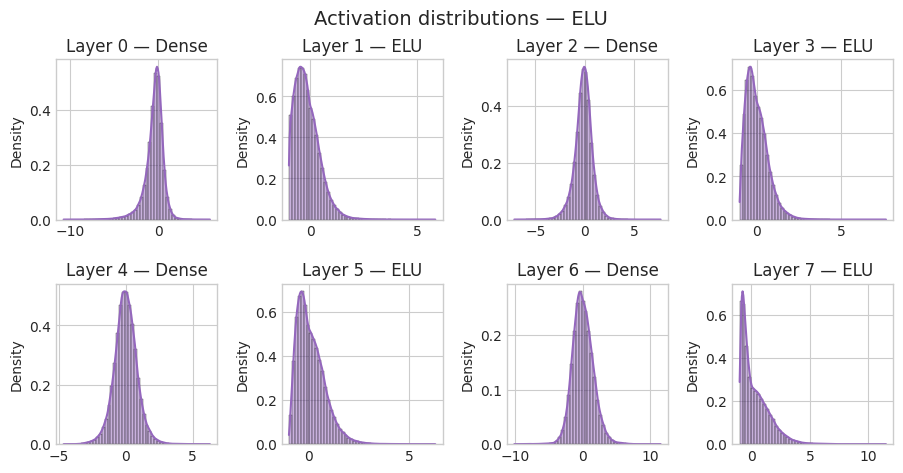

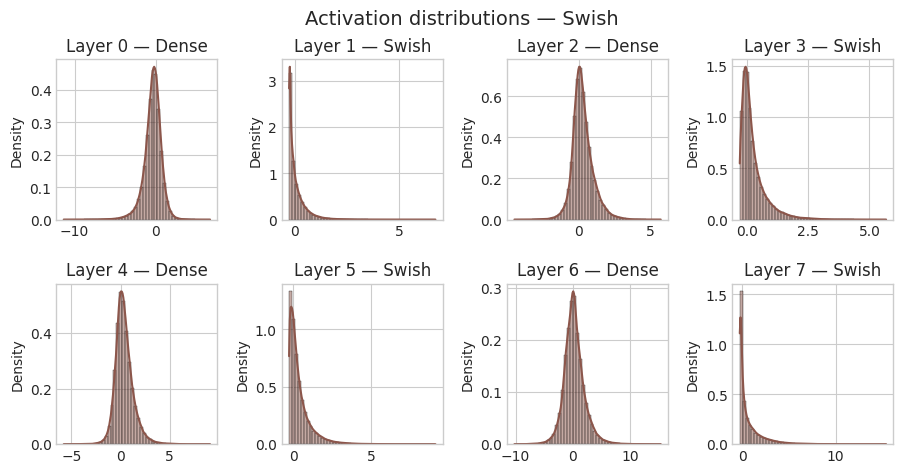

In [33]:
def visualize_activations(net, params, color="C0"):
    """Plot activation value distributions for each layer in the trained network."""
    imgs, labels = exmp_batch
    _, activations = net.apply(params, imgs, return_activations=True)

    cols = 4
    rows = math.ceil(len(activations) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.7, rows * 2.5))
    act_fn_name = net.act_fn.__class__.__name__
    for idx, activ in enumerate(activations):
        r, c = divmod(idx, cols)
        ax = axes[r][c] if rows > 1 else axes[c]
        sns.histplot(
            data=np.array(activ).reshape(-1), bins=50, ax=ax,
            color=color, kde=True, stat="density",
        )
        layer_type = "Dense" if idx % 2 == 0 else act_fn_name
        ax.set_title(f"Layer {idx} — {layer_type}")
    fig.suptitle(f"Activation distributions — {act_fn_name}", fontsize=14)
    fig.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()


for i, (name, act_cls) in enumerate(act_fn_by_name.items()):
    net = BaseNetwork(act_fn=act_cls())
    state = results[name]["state"]
    visualize_activations(net, state.params, color=f"C{i}")

**Observations**:
- **Sigmoid**: peaks cluster at 0 and 1 — the function saturates, and most neurons are "on" or "off"
- **Tanh**: peaks at $\pm 1$ in early layers, but inner layers settle closer to zero
- **ReLU**: sharp spike at 0 (all negative pre-activations collapse), long positive tail
- **LeakyReLU**: similar to ReLU but the negative side has a smooth (non-zero) tail
- **ELU**: more Gaussian-like distribution — healthy for gradient flow
- **Swish**: smooth distribution, values can range widely (up to ~15)

---

## 6 — Dead Neuron Analysis

A **dead neuron** is one whose ReLU output is exactly zero for *every* sample in the training set. Once dead, it receives zero gradient and can never recover.

We count dead neurons per layer across the full training set.

In [34]:
def measure_number_dead_neurons(net, params):
    """Count neurons with zero activation across the entire training set."""
    neurons_dead = [
        jnp.ones(hd, dtype=jnp.bool_) for hd in net.hidden_sizes
    ]
    get_activations = jax.jit(
        lambda inp: net.apply(params, inp, return_activations=True)[1]
    )
    for imgs, _ in tqdm(train_loader, leave=False, desc="Scanning"):
        activations = get_activations(imgs)
        for layer_idx, activ in enumerate(activations[1::2]):  # post-activation only
            neurons_dead[layer_idx] = jnp.logical_and(
                neurons_dead[layer_idx], (activ == 0).all(axis=0)
            )
    dead_counts = [int(t.sum()) for t in neurons_dead]
    print(f"  Dead neurons per layer: {dead_counts}")
    print(f"  Dead %: {', '.join(f'{d/s:.1%}' for d, s in zip(dead_counts, net.hidden_sizes))}")
    return dead_counts

### Standard network (4 layers): ReLU before and after training

In [35]:
# Dead neurons in the UNTRAINED ReLU network
print("Untrained ReLU network:")
net_relu = BaseNetwork(act_fn=ReLU())
untrained_params = net_relu.init(random.PRNGKey(42), exmp_batch[0])
_ = measure_number_dead_neurons(net_relu, untrained_params)

# Dead neurons in the TRAINED ReLU network
print("\nTrained ReLU network:")
_ = measure_number_dead_neurons(net_relu, results["relu"]["state"].params)

Untrained ReLU network:


Scanning:   0%|          | 0/49 [00:00<?, ?it/s]

  Dead neurons per layer: [0, 0, 2, 13]
  Dead %: 0.0%, 0.0%, 0.8%, 10.2%

Trained ReLU network:


Scanning:   0%|          | 0/49 [00:00<?, ?it/s]

  Dead neurons per layer: [0, 0, 2, 4]
  Dead %: 0.0%, 0.0%, 0.8%, 3.1%


### Deep network (10 layers): the dead neuron problem escalates

With more layers, dead neurons compound — later layers receive increasingly sparse inputs, causing even more neurons to die.

In [36]:
# 10-layer ReLU network — dead neurons get much worse
deep_sizes = (256, 256, 256, 256, 256, 128, 128, 128, 128, 128)
net_deep = BaseNetwork(act_fn=ReLU(), hidden_sizes=deep_sizes)
deep_params = net_deep.init(random.PRNGKey(42), exmp_batch[0])

print("10-layer untrained ReLU network:")
_ = measure_number_dead_neurons(net_deep, deep_params)

10-layer untrained ReLU network:


Scanning:   0%|          | 0/49 [00:00<?, ?it/s]

  Dead neurons per layer: [0, 2, 3, 26, 72, 53, 67, 65, 57, 59]
  Dead %: 0.0%, 0.8%, 1.2%, 10.2%, 28.1%, 41.4%, 52.3%, 50.8%, 44.5%, 46.1%


In a 10-layer network, over **50% of neurons** in later layers can be dead before training even starts. This is why deeper ReLU networks often use **LeakyReLU**, **ELU**, or **Swish** — they guarantee non-zero gradients for negative inputs, preventing permanent neuron death.

---

## Summary

| Activation | Test Acc | Vanishing Grad? | Dead Neurons? | Best for |
|-----------|----------|----------------|--------------|----------|
| Sigmoid | ~78% | Yes (severe) | No | Legacy / output gates |
| Tanh | ~88% | Mild | No | RNNs, bounded outputs |
| ReLU | ~88% | No | Yes | Default starting point |
| LeakyReLU | ~88% | No | No | Deep networks |
| ELU | ~88% | No | No | When mean-zero activations matter |
| Swish | ~88% | No | No | Deep networks, smooth optimization |

**Practical advice**:
1. **Start with ReLU** — it's fast, simple, and works well for most architectures
2. **Switch to LeakyReLU/ELU/Swish** when building deeper networks (>5 layers) where dead neurons become a risk
3. **Avoid Sigmoid** in hidden layers — its vanishing gradients cripple learning in all but the shallowest networks
4. **Initialization matters** as much as activation choice — Tutorial 4 (next) explores this in depth